# OOTP Free Agency Valuation — Frostfire 2035

Predicts market-rate salaries for players entering free agency after the **2035 season**
using separate XGBoost models for position players, starting pitchers, and relief pitchers.

**Washington Nationals** free agents are highlighted throughout.

**Workflow:**
1. Load player/contract/stat data
2. Identify contracts expiring after 2035
3. Engineer 40+ weighted features (rate stats, WAR trends, age curves, fielding)
4. Train XGBoost regressors on existing contract salaries as market-price signal
5. Apply models to free-agent candidates
6. Visualise results and export CSV


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import xgboost as xgb
import shap

from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams['figure.figsize'] = (13, 6)
sns.set_style('whitegrid')

# ── Constants ─────────────────────────────────────────────────────────
DATA_DIR      = Path('frostfire_data')
CURRENT_YEAR  = 2035
FA_YEAR       = 2035          # contracts expiring end of this season
WAR_YEARS     = [2031, 2032, 2033]
WAR_WEIGHTS   = {2031: 1, 2032: 2, 2033: 3}
TOTAL_W       = sum(WAR_WEIGHTS.values())   # 6
NATS_ID       = 30            # Washington Nationals team ID
EPS           = 1e-9          # guard against divide-by-zero

MIN_PA_BATTER = 50            # min weighted-avg PA to include batter in training
MIN_IP_PITCH  = 10            # min weighted-avg IP to include pitcher in training
MIN_SALARY    = 800_000       # exclude pre-arb minimums from training target


In [2]:
# ── Core tables ──────────────────────────────────────────────────────
players   = pd.read_csv(DATA_DIR / 'players.csv')
contracts = pd.read_csv(DATA_DIR / 'contracts.csv')
teams     = pd.read_csv(DATA_DIR / 'teams.csv')

# Normalise players columns (contain spaces / mixed case)
players.columns = (players.columns
                   .str.strip()
                   .str.lower()
                   .str.replace(r'[\s]+', '_', regex=True)
                   .str.replace(r'[()]', '', regex=True))

# ── Year-by-year stat files (WAR window 2031-2033) ────────────────────
batting_years  = {}
pitching_years = {}
fielding_years = {}
for yr in WAR_YEARS:
    batting_years[yr]  = pd.read_csv(DATA_DIR / f'player_batting_{yr}.csv')
    pitching_years[yr] = pd.read_csv(DATA_DIR / f'player_pitching_{yr}.csv')
    fielding_years[yr] = pd.read_csv(DATA_DIR / f'player_fielding_{yr}.csv')

# ── Career stats (all seasons 2015-2033) ──────────────────────────────
_bf, _pf = [], []
for yr in range(2015, 2034):
    _bf.append(pd.read_csv(DATA_DIR / f'player_batting_{yr}.csv'))
    _pf.append(pd.read_csv(DATA_DIR / f'player_pitching_{yr}.csv'))
career_batting  = pd.concat(_bf, ignore_index=True)
career_pitching = pd.concat(_pf, ignore_index=True)
del _bf, _pf

print(f'Players:          {len(players):,}')
print(f'Contracts:        {len(contracts):,}')
print(f'Career bat rows:  {len(career_batting):,}')
print(f'Career pit rows:  {len(career_pitching):,}')


Players:          136,174
Contracts:        7,263
Career bat rows:  27,121
Career pit rows:  35,668


In [3]:
print('=== Batting 2033 — split_id distribution ===')
print(batting_years[2033]['split_id'].value_counts().sort_index())
print()
print('=== Batting 2033 — level_id distribution ===')
print(batting_years[2033]['level_id'].value_counts().sort_index())
print()
print('=== Contracts — season_year distribution ===')
print(contracts['season_year'].value_counts().sort_index())
print()
print('=== Contracts — is_major distribution ===')
print(contracts['is_major'].value_counts())
print()
sample_cols = ['player_id', 'season_year', 'years', 'current_year', 'salary0', 'salary1', 'salary2']
print('=== Sample multi-year contracts ===')
print(contracts[contracts['years'] > 3][sample_cols].head(5).to_string(index=False))


=== Batting 2033 — split_id distribution ===
split_id
1     413
2     409
3     412
21    103
Name: count, dtype: int64

=== Batting 2033 — level_id distribution ===
level_id
1    1337
Name: count, dtype: int64

=== Contracts — season_year distribution ===
season_year
0       6362
2031       1
2032       9
2033      20
2034      44
2035     827
Name: count, dtype: int64

=== Contracts — is_major distribution ===
is_major
0    4358
1    2905
Name: count, dtype: int64

=== Sample multi-year contracts ===
 player_id  season_year  years  current_year  salary0  salary1  salary2
       109         2035      5             0 21000000 23200000 23200000
     23185         2035      5             0  8800000 17700000 18000000
     23299         2035      4             0 29000000 26500000 20200000
     23334         2035      5             0  5500000  7500000  7500000
     24549         2035      5             0 40200000 41200000 41000000


In [4]:
# Current salary = salary{current_year} column
salary_cols = [f'salary{i}' for i in range(15)]
cy_idx = contracts['current_year'].astype(int).clip(0, 14).values
contracts['current_salary'] = contracts[salary_cols].values[np.arange(len(contracts)), cy_idx]

# Contract end year
contracts['end_year'] = contracts['season_year'] + contracts['years'] - 1

# Free agents: MLB contracts expiring after the 2035 season
fa_mask = (
    (contracts['end_year'] == FA_YEAR) &
    (contracts['season_year'] > 0) &
    (contracts['is_major'] == 1)
)
fa_contracts = contracts[fa_mask].copy()
fa_contracts['is_nationals'] = fa_contracts['team_id'] == NATS_ID

# Merge player bio info
bio_cols = [c for c in ['id', 'first_name', 'last_name', 'age', 'pos', 'bats', 'throws',
                         'height', 'weight', 'mlb_service_years', 'mlb_service_days',
                         'draft_overall_pick', 'was_traded', 'is_on_dl']
            if c in players.columns]
fa_merged = fa_contracts.merge(players[bio_cols], left_on='player_id', right_on='id', how='left')
fa_merged['name'] = (fa_merged['first_name'].fillna('') + ' ' +
                     fa_merged['last_name'].fillna('')).str.strip()

print(f'Free agents expiring after {FA_YEAR}: {len(fa_merged)}')
print(f'Nationals FAs: {fa_merged["is_nationals"].sum()}')
print()
nats = fa_merged[fa_merged['is_nationals']][['name', 'pos', 'age', 'current_salary']].copy()
nats['current_salary'] = nats['current_salary'].apply(lambda x: f'${x:,.0f}')
print('Nationals free agents:')
print(nats.to_string(index=False))


Free agents expiring after 2035: 785
Nationals FAs: 27

Nationals free agents:
             name  pos  age current_salary
         Eric Ely    1   24       $750,000
    Jonathan Ruiz    8   23       $750,000
      Jerry Hudak    1   23       $750,000
    Matt Kreisman    1   25       $750,000
      Alex Moreau    2   26       $750,000
   Willie Morales    3   24       $750,000
        Chris Kay    7   24       $750,000
     Mark Burgess    1   26       $750,000
      Mark Haynes    9   24       $750,000
    Miguel Romero    1   25       $750,000
     Bobby Newman    6   25       $750,000
    Justin Cooper    4   24       $750,000
    Pat Cullinane    1   25       $750,000
   Bryan Shearing    9   26       $750,000
      Justin Lyon    1   27       $750,000
   Travis Kushner    1   27     $1,300,000
      Josh Reilly    1   22       $750,000
Justus Mierkowicz    6   22       $750,000
       Jose Silva    1   22       $750,000
     Jose Fregoso    6   22       $750,000
  Nick Massengale 

In [5]:
def _bat_season_agg(df):
    '''Sum batting stats per player-season (MLB level, overall split only).'''
    mlb = df[(df['level_id'] == 1) & (df['split_id'] == 1)].copy()
    count_cols = [c for c in ['pa','ab','h','k','d','t','hr','r','rbi',
                               'sb','cs','bb','ibb','gdp','sh','sf','hp',
                               'wpa','ubr','war','g','gs']
                  if c in mlb.columns]
    agg = mlb.groupby(['player_id', 'year'])[count_cols].sum().reset_index()
    if 'position' in mlb.columns:
        pos = (mlb.groupby(['player_id', 'year', 'position'])['pa']
                  .sum().reset_index()
                  .sort_values('pa', ascending=False)
                  .drop_duplicates(['player_id', 'year'])
               [['player_id', 'year', 'position']])
        agg = agg.merge(pos, on=['player_id', 'year'], how='left')
    return agg


def _pit_season_agg(df):
    '''Sum pitching stats per player-season (MLB level, overall split only).'''
    mlb = df[(df['level_id'] == 1) & (df['split_id'] == 1)].copy()
    count_cols = [c for c in ['ip','ha','k','bf','bb','r','er','gb','fb',
                               'g','gs','w','l','s','hra','bk','wp','hp',
                               'qs','svo','bs','cg','hld','ir','irs',
                               'wpa','war','ra9war','sd','md']
                  if c in mlb.columns]
    return mlb.groupby(['player_id', 'year'])[count_cols].sum().reset_index()


def weighted_bat_features(player_ids, bat_dict, weights):
    '''Build 3-year weighted batting feature DataFrame.'''
    frames = []
    for yr, w in weights.items():
        s = _bat_season_agg(bat_dict[yr])
        s['_w'] = w
        frames.append(s)
    df = pd.concat(frames, ignore_index=True)
    df = df[df['player_id'].isin(player_ids)]

    count_cols = [c for c in ['pa','ab','h','k','d','t','hr','r','rbi',
                               'sb','cs','bb','ibb','gdp','sh','sf','hp',
                               'wpa','ubr','war','g']
                  if c in df.columns]
    for c in count_cols:
        df[f'_w{c}'] = df[c] * df['_w']
    agg = df.groupby('player_id')[[f'_w{c}' for c in count_cols] + ['_w']].sum().reset_index()
    for c in count_cols:
        agg[c] = agg[f'_w{c}'] / TOTAL_W
        agg.drop(columns=[f'_w{c}'], inplace=True)
    agg.rename(columns={'war': 'weighted_war', '_w': '_tw'}, inplace=True)

    if 'position' in df.columns:
        recent_pos = df.sort_values('year').groupby('player_id')['position'].last()
        agg = agg.merge(recent_pos.rename('batting_pos'), on='player_id', how='left')

    war_piv = df.pivot_table(index='player_id', columns='year', values='war', aggfunc='sum')
    war_piv.columns = [f'war_{c}' for c in war_piv.columns]
    agg = agg.merge(war_piv.reset_index(), on='player_id', how='left')

    y_lo = f'war_{WAR_YEARS[0]}'
    y_hi = f'war_{WAR_YEARS[-1]}'
    agg['war_trend'] = (agg.get(y_hi, pd.Series(0.0, index=agg.index)).fillna(0)
                      - agg.get(y_lo, pd.Series(0.0, index=agg.index)).fillna(0))
    agg['seasons_bat'] = (df.groupby('player_id')['year'].nunique()
                            .reindex(agg['player_id'].values).values)

    sg = agg['h'] - agg['d'] - agg['t'] - agg['hr']
    agg['avg']          = agg['h']  / (agg['ab'] + EPS)
    agg['obp']          = (agg['h'] + agg['bb'] + agg['hp']) / (agg['ab'] + agg['bb'] + agg['hp'] + agg['sf'] + EPS)
    agg['slg']          = (sg + 2*agg['d'] + 3*agg['t'] + 4*agg['hr']) / (agg['ab'] + EPS)
    agg['iso']          = agg['slg'] - agg['avg']
    agg['babip']        = (agg['h'] - agg['hr']) / (agg['ab'] - agg['k'] - agg['hr'] + agg['sf'] + EPS)
    agg['woba']         = (0.69*agg['bb'] + 0.72*agg['hp'] + 0.89*sg
                           + 1.27*agg['d'] + 1.62*agg['t'] + 2.10*agg['hr']) / (agg['pa'] + EPS)
    agg['bb_rate']      = agg['bb'] / (agg['pa'] + EPS)
    agg['k_rate']       = agg['k']  / (agg['pa'] + EPS)
    agg['contact_rate'] = (agg['ab'] - agg['k']) / (agg['ab'] + EPS)
    agg['hr_rate']      = agg['hr'] / (agg['pa'] + EPS)
    agg['ibb_rate']     = agg['ibb'] / (agg['pa'] + EPS)
    agg['xbh_rate']     = (agg['d'] + agg['t'] + agg['hr']) / (agg['pa'] + EPS)
    agg['sb_net']       = agg['sb'] - agg['cs']
    agg['sb_rate']      = agg['sb'] / (agg['sb'] + agg['cs'] + EPS)
    agg['gdp_rate']     = agg['gdp'] / (agg['pa'] + EPS)
    agg['pa_per_162']   = agg['pa'] / (agg['g'] + EPS) * 162
    agg['hr_per_600pa'] = agg['hr'] / (agg['pa'] + EPS) * 600
    agg['rbi_per_pa']   = agg['rbi'] / (agg['pa'] + EPS)
    agg['runs_per_pa']  = agg['r']   / (agg['pa'] + EPS)
    agg.drop(columns=['_tw'], inplace=True, errors='ignore')
    return agg


def weighted_pit_features(player_ids, pit_dict, weights):
    '''Build 3-year weighted pitching feature DataFrame.'''
    frames = []
    for yr, w in weights.items():
        s = _pit_season_agg(pit_dict[yr])
        s['_w'] = w
        frames.append(s)
    df = pd.concat(frames, ignore_index=True)
    df = df[df['player_id'].isin(player_ids)]

    count_cols = [c for c in ['ip','ha','k','bf','bb','r','er','gb','fb',
                               'g','gs','w','l','s','hra','bk','wp','hp',
                               'qs','svo','bs','cg','hld','ir','irs',
                               'wpa','war','ra9war','sd','md']
                  if c in df.columns]
    for c in count_cols:
        df[f'_w{c}'] = df[c] * df['_w']
    agg = df.groupby('player_id')[[f'_w{c}' for c in count_cols] + ['_w']].sum().reset_index()
    for c in count_cols:
        agg[c] = agg[f'_w{c}'] / TOTAL_W
        agg.drop(columns=[f'_w{c}'], inplace=True)
    agg.rename(columns={'war': 'weighted_war', 'ra9war': 'weighted_ra9war', '_w': '_tw'}, inplace=True)

    war_piv = df.pivot_table(index='player_id', columns='year', values='war', aggfunc='sum')
    war_piv.columns = [f'war_{c}' for c in war_piv.columns]
    agg = agg.merge(war_piv.reset_index(), on='player_id', how='left')

    y_lo = f'war_{WAR_YEARS[0]}'
    y_hi = f'war_{WAR_YEARS[-1]}'
    agg['war_trend'] = (agg.get(y_hi, pd.Series(0.0, index=agg.index)).fillna(0)
                      - agg.get(y_lo, pd.Series(0.0, index=agg.index)).fillna(0))
    agg['seasons_pit'] = (df.groupby('player_id')['year'].nunique()
                            .reindex(agg['player_id'].values).values)

    agg['is_starter']  = (agg['gs'] / (agg['g'] + EPS) > 0.5).astype(int)
    agg['gs_pct']      = agg['gs'] / (agg['g'] + EPS)
    agg['era']         = agg['er'] / (agg['ip'] + EPS) * 9
    agg['whip']        = (agg['ha'] + agg['bb']) / (agg['ip'] + EPS)
    agg['k9']          = agg['k']  / (agg['ip'] + EPS) * 9
    agg['bb9']         = agg['bb'] / (agg['ip'] + EPS) * 9
    agg['hr9']         = agg['hra'] / (agg['ip'] + EPS) * 9
    agg['k_bb']        = agg['k']  / (agg['bb'] + EPS)
    agg['fip']         = (13*agg['hra'] + 3*(agg['bb'] + agg['hp']) - 2*agg['k']) / (agg['ip'] + EPS) + 3.1
    agg['gb_pct']      = agg['gb'] / (agg['gb'] + agg['fb'] + EPS)
    agg['hr_fb_pct']   = agg['hra'] / (agg['fb'] + EPS)
    if 'bf' in agg.columns:
        agg['babip_against']       = (agg['ha'] - agg['hra']) / (agg['bf'] - agg['k'] - agg['hra'] + EPS)
        agg['contact_pct_against'] = (agg['bf'] - agg['bb'] - agg['k'] - agg['hp']) / (agg['bf'] - agg['bb'] - agg['hp'] + EPS)
    agg['er_pct']        = agg['er'] / (agg['r'] + EPS)
    agg['lob_strand']    = (agg['ha'] + agg['bb'] - agg['r']) / (agg['ha'] + agg['bb'] + EPS)
    agg['ip_per_season'] = agg['ip']
    agg['ip_per_start']  = agg['ip'] / (agg['gs'] + EPS)
    agg['qs_pct']        = agg['qs'] / (agg['gs'] + EPS)
    if 'cg' in agg.columns:
        agg['cg_pct'] = agg['cg'] / (agg['gs'] + EPS)
    hld = agg['hld'] if 'hld' in agg.columns else pd.Series(0.0, index=agg.index)
    agg['sv_hld']          = agg['s'] + hld.fillna(0)
    agg['sv_pct']          = agg['s'] / (agg['svo'] + EPS)
    agg['blown_save_rate'] = agg['bs']  / (agg['svo'] + EPS)
    if 'ir' in agg.columns:
        agg['ir_strand_rate'] = 1 - agg['irs'] / (agg['ir'] + EPS)
    if 'sd' in agg.columns and 'md' in agg.columns:
        agg['sd_md_ratio'] = agg['sd'] / (agg['sd'] + agg['md'] + EPS)
    if 'bk' in agg.columns:
        agg['bk_per_ip'] = agg['bk'] / (agg['ip'] + EPS)
    agg['wp_per_ip'] = agg['wp'] / (agg['ip'] + EPS)
    agg.drop(columns=['_tw'], inplace=True, errors='ignore')
    return agg


def career_war_features(bat_df, pit_df):
    '''Career WAR total and peak single-season WAR from all available seasons.'''
    bat = bat_df[(bat_df['level_id'] == 1) & (bat_df['split_id'] == 1)]
    pit = pit_df[(pit_df['level_id'] == 1) & (pit_df['split_id'] == 1)]
    bat_c = bat.groupby('player_id')['war'].sum().rename('career_war_bat')
    pit_c = pit.groupby('player_id')['war'].sum().rename('career_war_pit')
    bat_p = bat.groupby(['player_id','year'])['war'].sum().groupby('player_id').max().rename('peak_war_bat')
    pit_p = pit.groupby(['player_id','year'])['war'].sum().groupby('player_id').max().rename('peak_war_pit')
    c = pd.concat([bat_c, pit_c, bat_p, pit_p], axis=1).fillna(0)
    c['career_war'] = c['career_war_bat'] + c['career_war_pit']
    c['peak_war']   = c[['peak_war_bat', 'peak_war_pit']].max(axis=1)
    return c.reset_index()[['player_id', 'career_war', 'peak_war']]


def weighted_field_features(player_ids, field_dict, weights):
    '''3-year weighted fielding features: zr, framing, arm.'''
    frames = []
    for yr, w in weights.items():
        df  = field_dict[yr]
        mlb = df[(df['level_id'] == 1) & (df['split_id'] == 1)].copy()
        fcols = [c for c in ['g', 'zr', 'framing', 'arm'] if c in mlb.columns]
        if 'g' not in fcols:
            continue
        a = mlb.groupby('player_id')[fcols].sum().reset_index()
        a['_w'] = w
        frames.append(a)
    if not frames:
        return pd.DataFrame(columns=['player_id'])
    df_all = pd.concat(frames, ignore_index=True)
    df_all = df_all[df_all['player_id'].isin(player_ids)]
    for c in ['zr', 'framing', 'arm']:
        if c in df_all.columns:
            df_all[f'_w{c}'] = df_all[c] * df_all['_w']
    w_cols = [f for f in ['_wzr', '_wframing', '_warm'] if f in df_all.columns]
    feat = df_all.groupby('player_id')[w_cols + ['_w']].sum().reset_index()
    for c in ['zr', 'framing', 'arm']:
        if f'_w{c}' in feat.columns:
            feat[c] = feat[f'_w{c}'] / TOTAL_W
            feat.drop(columns=[f'_w{c}'], inplace=True)
    feat.drop(columns=['_w'], inplace=True)
    return feat


def add_player_bio(feat_df, players_df):
    '''Merge age, position, physical attributes, service time.'''
    keep = [c for c in ['id', 'age', 'pos', 'bats', 'throws', 'height', 'weight',
                         'mlb_service_years', 'mlb_service_days', 'draft_overall_pick', 'was_traded']
            if c in players_df.columns]
    bio  = players_df[keep].rename(columns={'id': 'player_id', 'pos': 'player_pos'})
    out  = feat_df.merge(bio, on='player_id', how='left')
    out['age']               = pd.to_numeric(out['age'], errors='coerce')
    out['age_sq']            = out['age'] ** 2
    out['yrs_from_peak_bat'] = np.maximum(0, out['age'] - 28)
    out['yrs_from_peak_pit'] = np.maximum(0, out['age'] - 29)
    return out

print('Feature engineering functions defined.')


Feature engineering functions defined.


In [6]:
all_ids = list(set(contracts['player_id'].unique()) | set(fa_merged['player_id'].unique()))
print(f'Computing features for {len(all_ids):,} players...')

bat_feat   = weighted_bat_features(all_ids, batting_years,  WAR_WEIGHTS)
pit_feat   = weighted_pit_features(all_ids, pitching_years, WAR_WEIGHTS)
career     = career_war_features(career_batting, career_pitching)
field_feat = weighted_field_features(all_ids, fielding_years, WAR_WEIGHTS)

print(f'  Batting:  {len(bat_feat):,} players x {bat_feat.shape[1]} features')
print(f'  Pitching: {len(pit_feat):,} players x {pit_feat.shape[1]} features')
print(f'  Career:   {len(career):,} players')
print(f'  Fielding: {len(field_feat):,} players')


Computing features for 7,263 players...
  Batting:  468 players x 47 features
  Pitching: 428 players x 62 features
  Career:   3,797 players
  Fielding: 0 players


In [7]:
# Players with >= MIN_IP_PITCH weighted-avg IP are classified as pitchers
pit_player_ids = set(pit_feat[pit_feat['ip'] >= MIN_IP_PITCH]['player_id'])

# ── Batter master (pitchers excluded) ────────────────────────────────
bat_master = (
    bat_feat[~bat_feat['player_id'].isin(pit_player_ids)]
    .merge(career,     on='player_id', how='left')
    .merge(field_feat, on='player_id', how='left')
    .pipe(add_player_bio, players)
)

# ── Pitcher master ────────────────────────────────────────────────────
pit_master = (
    pit_feat[pit_feat['player_id'].isin(pit_player_ids)]
    .merge(career, on='player_id', how='left')
    .pipe(add_player_bio, players)
)

print(f'Batters:  {len(bat_master):,}')
print(f'Pitchers: {len(pit_master):,}  (SP: {pit_master["is_starter"].sum():,}  RP: {(pit_master["is_starter"]==0).sum():,})')


Batters:  463
Pitchers: 377  (SP: 136  RP: 241)


In [8]:
# Training = all players with an above-minimum MLB contract in the snapshot
train_base = contracts[
    (contracts['is_major'] == 1) &
    (contracts['current_salary'] >= MIN_SALARY) &
    (contracts['season_year'] > 0)
].copy()

bat_train = train_base.merge(bat_master, on='player_id', how='inner')
bat_train = bat_train[bat_train['pa'] >= MIN_PA_BATTER].copy()
bat_train['log_salary'] = np.log1p(bat_train['current_salary'])

pit_train = train_base.merge(pit_master, on='player_id', how='inner')
pit_train = pit_train[pit_train['ip'] >= MIN_IP_PITCH].copy()
pit_train['log_salary'] = np.log1p(pit_train['current_salary'])

sp_train = pit_train[pit_train['is_starter'] == 1].copy()
rp_train = pit_train[pit_train['is_starter'] == 0].copy()

print(f'Batter training rows: {len(bat_train):,}')
print(f'SP training rows:     {len(sp_train):,}')
print(f'RP training rows:     {len(rp_train):,}')
print()
print('Batter salary (M$):')
print((bat_train['current_salary'] / 1e6).describe().round(2))


Batter training rows: 148
SP training rows:     77
RP training rows:     101

Batter salary (M$):
count   148.000
mean     10.410
std      12.430
min       0.850
25%       2.640
50%       4.510
75%      11.670
max      50.400
Name: current_salary, dtype: float64


In [9]:
# Columns to drop before building the feature matrix
_DROP = set(
    ['player_id', 'id', 'team_id', 'league_id', 'is_major', 'no_trade',
     'last_year_team_option', 'last_year_player_option', 'last_year_vesting_option',
     'next_last_year_team_option', 'next_last_year_player_option', 'next_last_year_vesting_option',
     'contract_team_id', 'contract_league_id', 'season_year', 'years', 'current_year',
     'minimum_pa', 'minimum_pa_bonus', 'minimum_ip', 'minimum_ip_bonus',
     'mvp_bonus', 'cyyoung_bonus', 'allstar_bonus',
     'next_last_year_option_buyout', 'last_year_option_buyout',
     'current_salary', 'end_year', 'is_nationals', 'log_salary',
     'first_name', 'last_name', 'name', 'date_of_birth']
  + [f'salary{i}' for i in range(15)]
  + [f'war_{yr}' for yr in WAR_YEARS]   # trend already captured
)

_CAT_COLS = ['batting_pos', 'player_pos', 'bats', 'throws']

_XGB_PARAMS = {
    'n_estimators':     [300, 500, 800],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.85, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [1, 2, 5],
}


def prepare_X(df, extra_drop=None):
    '''Build clean feature matrix for XGBoost (categoricals + NaN fill).'''
    drop = _DROP.copy()
    if extra_drop:
        drop |= set(extra_drop)
    X = df.drop(columns=[c for c in drop if c in df.columns], errors='ignore').copy()
    for c in _CAT_COLS:
        if c in X.columns:
            X[c] = X[c].astype('category')
    num_cols = X.select_dtypes(include=[np.number]).columns
    X[num_cols] = X[num_cols].fillna(0)
    return X


def train_xgb(train_df, label='Model', n_iter=25, cv=5):
    '''Train XGBoost regressor; return (best_model, X_train).'''
    X = prepare_X(train_df)
    y = train_df['log_salary'].values
    base = xgb.XGBRegressor(enable_categorical=True, random_state=42,
                             n_jobs=-1, tree_method='hist')
    search = RandomizedSearchCV(base, _XGB_PARAMS, n_iter=n_iter, cv=cv,
                                scoring='neg_mean_absolute_error',
                                random_state=42, n_jobs=-1, verbose=0)
    search.fit(X, y)
    best   = search.best_estimator_
    cv_r2  = cross_val_score(best, X, y, cv=cv, scoring='r2')
    mae    = mean_absolute_error(np.expm1(y), np.expm1(best.predict(X)))
    bp     = search.best_params_
    print(f'{label:<22}  R2={cv_r2.mean():.3f}+/-{cv_r2.std():.3f}  '
          f'train MAE=${mae/1e6:.2f}M  '
          f'n_est={bp["n_estimators"]}  depth={bp["max_depth"]}  lr={bp["learning_rate"]}')
    return best, X

print('Model helpers defined.')


Model helpers defined.


In [10]:
print('Training models (this may take 2-4 minutes)...')
bat_model, bat_X = train_xgb(bat_train, label='Position Players')
sp_model,  sp_X  = train_xgb(sp_train,  label='Starting Pitchers')
rp_model,  rp_X  = train_xgb(rp_train,  label='Relief Pitchers')
print('Done.')


Training models (this may take 2-4 minutes)...
Position Players        R2=0.581+/-0.109  train MAE=$1.72M  n_est=500  depth=3  lr=0.01
Starting Pitchers       R2=0.338+/-0.137  train MAE=$0.09M  n_est=500  depth=3  lr=0.05
Relief Pitchers         R2=0.601+/-0.144  train MAE=$0.07M  n_est=800  depth=3  lr=0.1
Done.


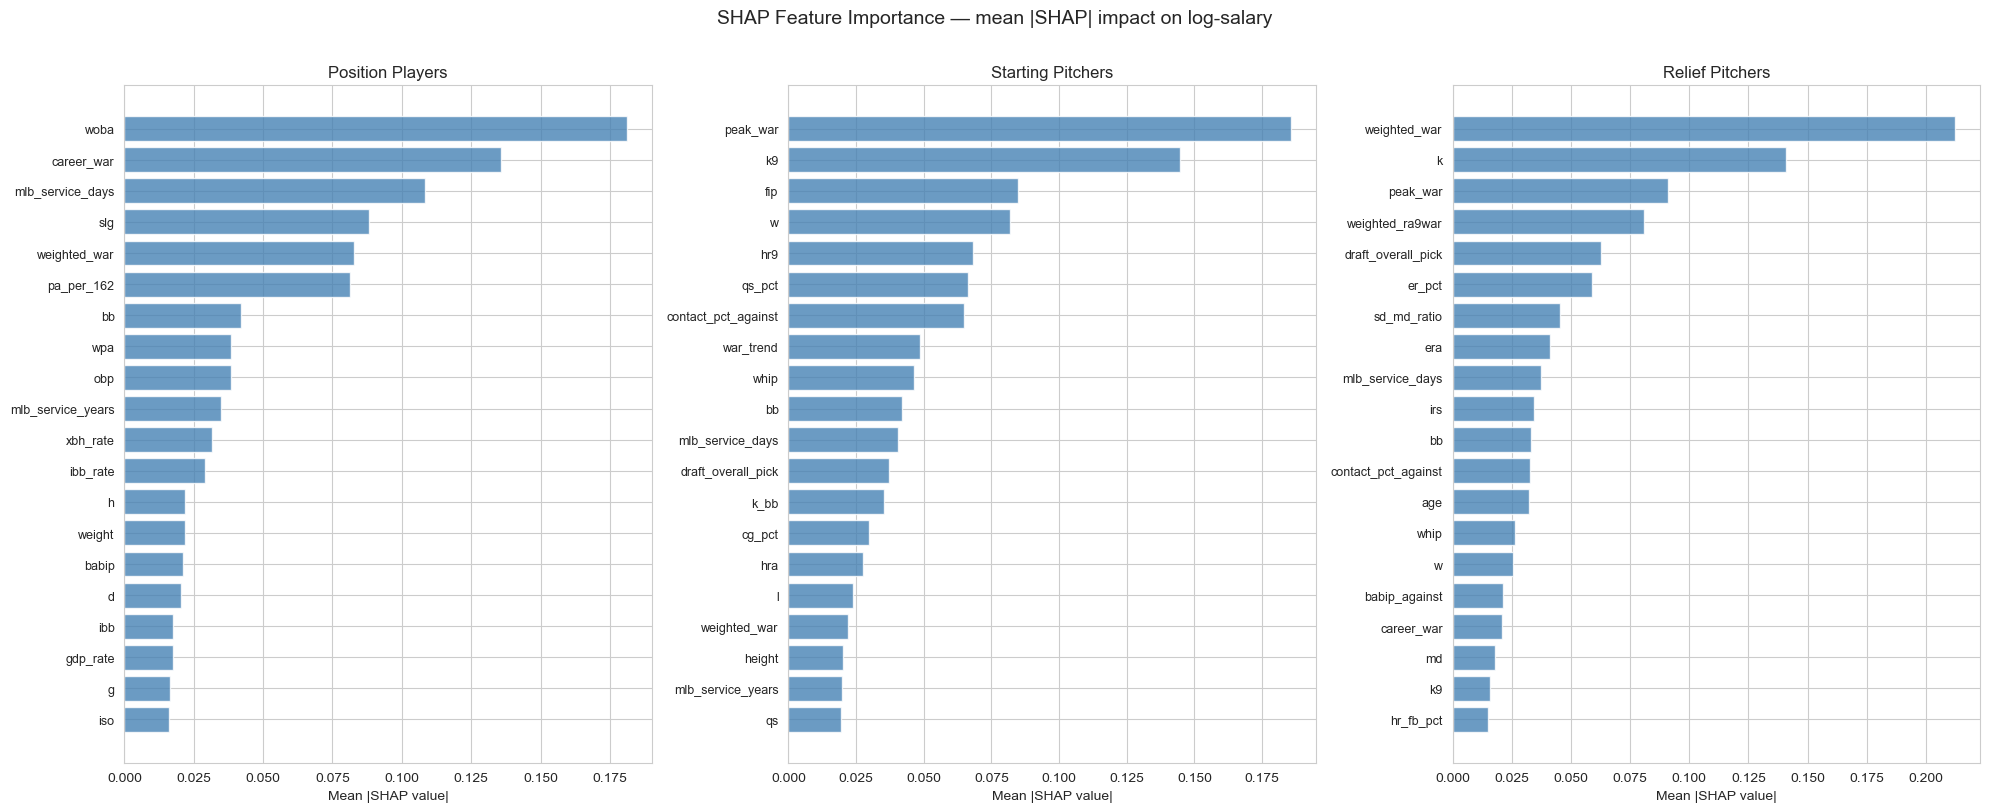

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('SHAP Feature Importance — mean |SHAP| impact on log-salary', fontsize=14, y=1.01)

for ax, model, X, title in [
    (axes[0], bat_model, bat_X, 'Position Players'),
    (axes[1], sp_model,  sp_X,  'Starting Pitchers'),
    (axes[2], rp_model,  rp_X,  'Relief Pitchers'),
]:
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X)
    mean_abs  = np.abs(shap_vals).mean(axis=0)
    n_show    = 20
    top_idx   = np.argsort(mean_abs)[-n_show:]
    top_feats = X.columns[top_idx]
    top_vals  = mean_abs[top_idx]

    ax.barh(range(n_show), top_vals, color='steelblue', alpha=0.8)
    ax.set_yticks(range(n_show))
    ax.set_yticklabels(top_feats, fontsize=9)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
def predict_salary(feat_df, model):
    '''Align columns to training set and return dollar AAV predictions.'''
    if len(feat_df) == 0:
        return np.array([], dtype=float)
    X = prepare_X(feat_df)
    train_cols = list(model.feature_names_in_)
    for c in train_cols:
        if c not in X.columns:
            X[c] = 0
    for c in _CAT_COLS:
        if c in X.columns:
            X[c] = X[c].astype('category')
    return np.expm1(model.predict(X[train_cols]))


# Split FA pool by player type
fa_pit_ids  = set(pit_master[pit_master['ip'] >= MIN_IP_PITCH]['player_id'])
fa_bat_pool = fa_merged[~fa_merged['player_id'].isin(fa_pit_ids)].copy()
fa_pit_pool = fa_merged[ fa_merged['player_id'].isin(fa_pit_ids)].copy()

fa_bat_feat = fa_bat_pool.merge(bat_master, on='player_id', how='inner')
fa_pit_feat = fa_pit_pool.merge(pit_master, on='player_id', how='inner')
fa_sp_feat  = fa_pit_feat[fa_pit_feat['is_starter'] == 1].copy()
fa_rp_feat  = fa_pit_feat[fa_pit_feat['is_starter'] == 0].copy()

fa_bat_feat['predicted_aav'] = predict_salary(fa_bat_feat, bat_model)
fa_bat_feat['player_type']   = 'Batter'
fa_sp_feat['predicted_aav']  = predict_salary(fa_sp_feat,  sp_model)
fa_sp_feat['player_type']    = 'SP'
fa_rp_feat['predicted_aav']  = predict_salary(fa_rp_feat,  rp_model)
fa_rp_feat['player_type']    = 'RP'

keep_cols = [c for c in ['player_id', 'name', 'team_id', 'pos', 'player_type', 'age',
                          'current_salary', 'weighted_war', 'war_trend',
                          'predicted_aav', 'is_nationals']
             if c in fa_bat_feat.columns]

fa_all = pd.concat([
    fa_bat_feat[[c for c in keep_cols if c in fa_bat_feat.columns]],
    fa_sp_feat [[c for c in keep_cols if c in fa_sp_feat.columns]],
    fa_rp_feat [[c for c in keep_cols if c in fa_rp_feat.columns]],
], ignore_index=True).sort_values('predicted_aav', ascending=False)

fa_all = fa_all.merge(
    teams.rename(columns={'ID': 'team_id', 'Name': 'team_name'})[['team_id', 'team_name']],
    on='team_id', how='left'
)
fa_all['team_name'] = fa_all['team_name'].fillna('Unknown')

missing = fa_merged[~fa_merged['player_id'].isin(fa_all['player_id'])]['name'].tolist()
print(f'Free agents valued:  {len(fa_all)}')
print(f'Skipped (no data):   {len(missing)}')
if missing:
    print(f'  Examples: {missing[:5]}')


Free agents valued:  450
Skipped (no data):   335
  Examples: ['Joseph Holloway', 'Xavier Davis', 'Danny Rendon', 'Brian McCall', 'Joel Swope']


In [13]:
def fmt_m(v):
    return f'${v/1e6:.1f}M' if v >= 1e6 else f'${v/1e3:.0f}K'

def show_table(df, title, n=30):
    t = df.head(n)
    show = [c for c in ['name','team_name','pos','player_type','age',
                         'weighted_war','war_trend','current_salary','predicted_aav']
            if c in t.columns]
    t = t[show].copy()
    for c in ['current_salary', 'predicted_aav']:
        if c in t.columns:
            t[c] = t[c].apply(fmt_m)
    t.columns = [c.replace('_',' ').title() for c in t.columns]
    sep = '-' * 90
    print(f'\n{sep}\n{title}\n{sep}')
    print(t.to_string(index=False))

# Nationals
nats_val = fa_all[fa_all.get('is_nationals', pd.Series(False, index=fa_all.index))]
show_table(nats_val, f'Washington Nationals FA Class -- {FA_YEAR}', n=50)

# Top 30 overall
show_table(fa_all, f'Top 30 Free Agents League-Wide -- {FA_YEAR}', n=30)



------------------------------------------------------------------------------------------
Washington Nationals FA Class -- 2035
------------------------------------------------------------------------------------------
          Name  Team Name  Pos Player Type  Weighted War  War Trend Current Salary Predicted Aav
Willie Morales Washington    3      Batter         0.569      1.138          $750K         $4.5M
  Mark Burgess Washington    1          RP         0.623      0.897          $750K         $4.2M
Bryan Shearing Washington    9      Batter         1.300      2.000          $750K         $3.6M
 Cameron Olson Washington    9      Batter        -0.022     -0.044          $750K         $2.6M
 Pat Cullinane Washington    1          RP        -0.400     -0.801          $750K         $2.5M
   Alex Moreau Washington    2      Batter         0.310      0.499          $750K         $2.4M
 Jonathan Ruiz Washington    8      Batter         0.124      0.248          $750K         $2.2M
Tra

KeyError: 'age'

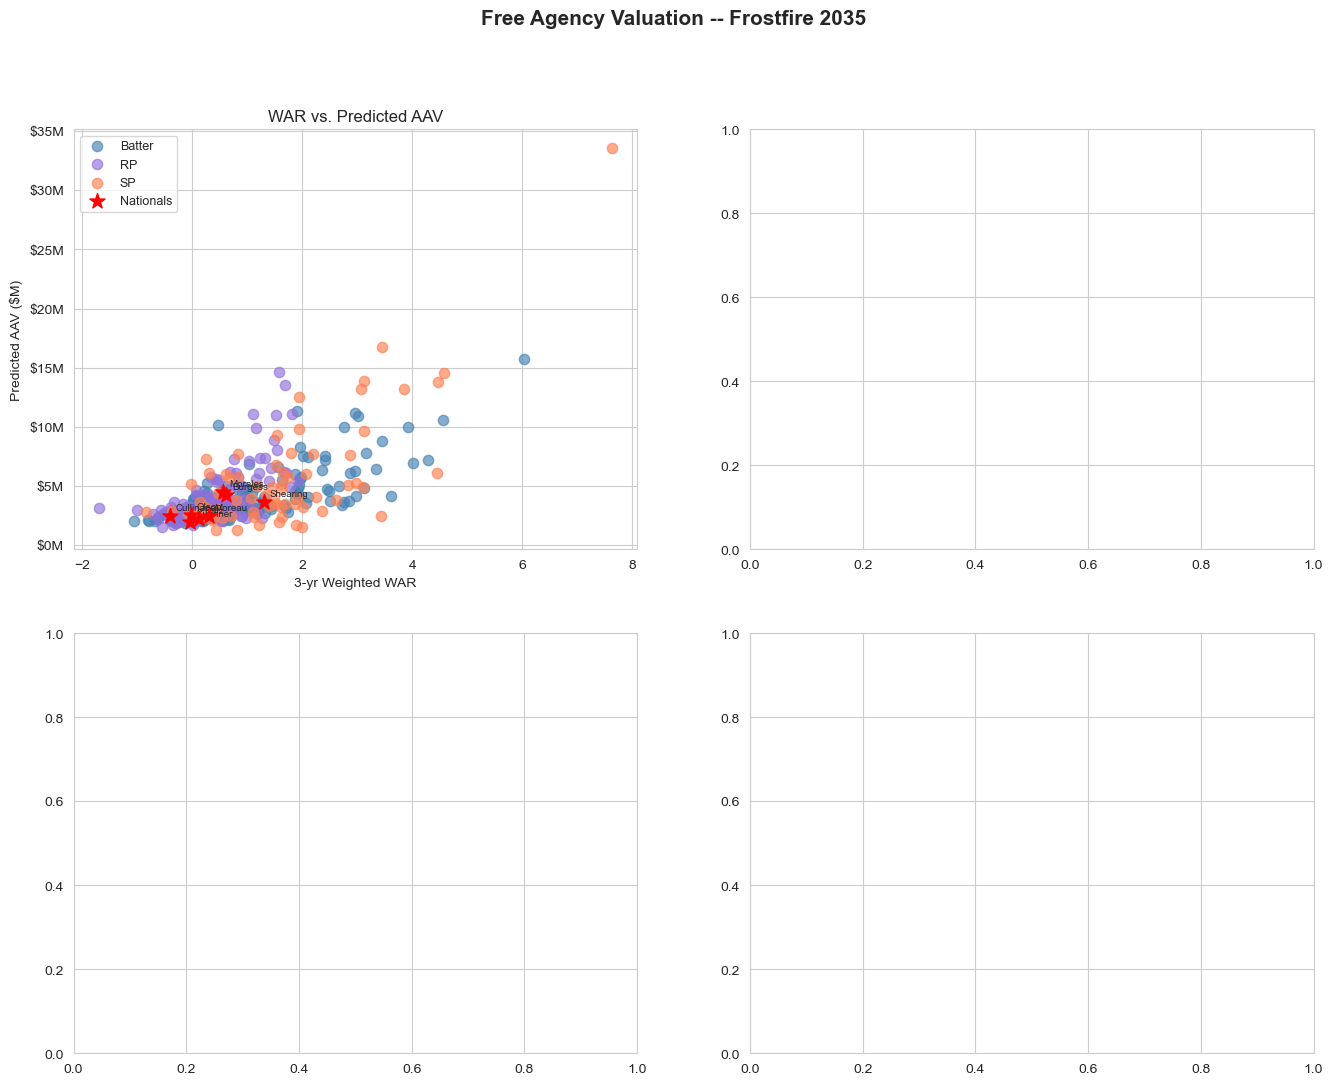

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Free Agency Valuation -- Frostfire {FA_YEAR}', fontsize=15, fontweight='bold')
ptype_colors = {'Batter': 'steelblue', 'SP': 'coral', 'RP': 'mediumpurple'}

# ── 1. WAR vs Predicted AAV ───────────────────────────────────────────
ax = axes[0, 0]
for ptype, grp in fa_all.groupby('player_type'):
    ax.scatter(grp['weighted_war'], grp['predicted_aav'] / 1e6,
               label=ptype, alpha=0.65, s=55, c=ptype_colors.get(ptype, 'gray'))
if 'is_nationals' in fa_all.columns:
    nh = fa_all[fa_all['is_nationals']]
    ax.scatter(nh['weighted_war'], nh['predicted_aav'] / 1e6,
               c='red', s=130, marker='*', zorder=5, label='Nationals')
    for _, r in nh.iterrows():
        last = str(r.get('name', '')).split()[-1]
        ax.annotate(last, (r['weighted_war'], r['predicted_aav']/1e6),
                    fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('3-yr Weighted WAR')
ax.set_ylabel('Predicted AAV ($M)')
ax.set_title('WAR vs. Predicted AAV')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.legend(fontsize=9)

# ── 2. Age vs Weighted WAR ────────────────────────────────────────────
ax = axes[0, 1]
for ptype, grp in fa_all.groupby('player_type'):
    ax.scatter(grp['age'], grp['weighted_war'],
               label=ptype, alpha=0.55, s=40, c=ptype_colors.get(ptype, 'gray'))
ax.axvline(28, color='green',  linestyle='--', lw=0.9, alpha=0.7, label='Batter peak ~28')
ax.axvline(29, color='orange', linestyle=':',  lw=0.9, alpha=0.7, label='Pitcher peak ~29')
ax.set_xlabel('Age')
ax.set_ylabel('3-yr Weighted WAR')
ax.set_title('Age vs. Weighted WAR')
ax.legend(fontsize=8)

# ── 3. Predicted AAV by Position ──────────────────────────────────────
ax = axes[1, 0]
pos_med  = fa_all.groupby('pos')['predicted_aav'].median().sort_values(ascending=False)
top_pos  = pos_med.head(10).index.tolist()
pos_data = [fa_all[fa_all['pos'] == p]['predicted_aav'].values / 1e6 for p in top_pos]
ax.boxplot(pos_data, labels=top_pos, showfliers=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.set_xlabel('Position')
ax.set_ylabel('Predicted AAV ($M)')
ax.set_title('Predicted AAV by Position')
plt.setp(ax.get_xticklabels(), rotation=30)

# ── 4. Nationals vs. Market Distribution ─────────────────────────────
ax = axes[1, 1]
is_nats = fa_all.get('is_nationals', pd.Series(False, index=fa_all.index))
rest    = fa_all[~is_nats]['predicted_aav'] / 1e6
nats_v  = fa_all[ is_nats]['predicted_aav'] / 1e6
ax.hist(rest,   bins=30, alpha=0.5,  label='All other FAs', color='steelblue')
ax.hist(nats_v, bins=10, alpha=0.85, label='Nationals FAs', color='red')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.set_xlabel('Predicted AAV ($M)')
ax.set_ylabel('Count')
ax.set_title('Nationals FA Class vs. Market')
ax.legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'fa_valuation_charts.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
out_path = DATA_DIR / f'free_agents_{FA_YEAR}_valuations.csv'
export = fa_all.copy()
for c in ['predicted_aav', 'current_salary']:
    if c in export.columns:
        export[c] = export[c].round(0).astype('Int64')
export.to_csv(out_path, index=False)

print(f'Saved {len(export)} rows -> {out_path}')
print()
print('Summary:')
print(f'  Total FAs valued:     {len(fa_all)}')
if 'is_nationals' in fa_all.columns:
    print(f'  Nationals FAs:        {fa_all["is_nationals"].sum()}')
print(f'  Median predicted AAV: {fmt_m(fa_all["predicted_aav"].median())}')
print(f'  Max predicted AAV:    {fmt_m(fa_all["predicted_aav"].max())}')
top = fa_all.iloc[0]
print(f'  Top FA: {top.get("name","?")} ({top["player_type"]}, age {top.get("age","?")})')
